# Task 1B: Data Cleaning
Cleaning the mental health smartphone dataset: handling erroneous values, missing data, and skewed distributions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 1. Load Data

In [2]:
df = pd.read_csv('../data/dataset_mood_smartphone.csv')
df['time'] = pd.to_datetime(df['time'])
df['date'] = df['time'].dt.date

print(f"Dataset shape: {df.shape}")
print(f"Number of patients: {df['id'].nunique()}")
print(f"Date range: {df['time'].min()} to {df['time'].max()}")
print(f"\nVariables ({df['variable'].nunique()}):")
print(df['variable'].unique())

Dataset shape: (376912, 6)
Number of patients: 27
Date range: 2014-02-17 07:00:52.197000 to 2014-06-09 00:00:00



Variables (19):
['mood' 'circumplex.arousal' 'circumplex.valence' 'activity' 'screen'
 'call' 'sms' 'appCat.builtin' 'appCat.communication'
 'appCat.entertainment' 'appCat.finance' 'appCat.game' 'appCat.office'
 'appCat.other' 'appCat.social' 'appCat.travel' 'appCat.unknown'
 'appCat.utilities' 'appCat.weather']


## 2. Domain-based Cleaning
We apply domain knowledge to fix clearly erroneous values. Variables have known valid ranges (mood 1-10, arousal/valence -2 to 2, activity 0-1). For app durations and screen time, negative values are sensor errors that we correct or remove.

In [3]:
df_clean = df.copy()

# --- 1. Show that call and sms only contain value=1 ---
print("=== Call and SMS value distributions ===")
for var in ['call', 'sms']:
    vals = df_clean.loc[df_clean['variable'] == var, 'value']
    print(f"  {var}: {len(vals)} rows, unique values = {sorted(vals.unique())}")
print("  -> When there is no row, it means 0 (no event). We will fill missing with 0 after pivoting.\n")

# --- 2. Show negative values per variable ---
print("=== Negative values per variable ===")
for var in df_clean['variable'].unique():
    neg = df_clean.loc[(df_clean['variable'] == var) & (df_clean['value'] < 0)]
    if len(neg) > 0:
        print(f"  {var}: {len(neg)} negative values, range [{neg['value'].min():.3f}, {neg['value'].max():.3f}]")

# --- 3. Fix negative app durations (take absolute value) ---
# Arousal and valence are validly negative (scale -2 to 2), so skip those
duration_vars = [v for v in df_clean['variable'].unique()
                 if v.startswith('appCat.') or v == 'screen']

changes_log = []

for var in duration_vars:
    mask = (df_clean['variable'] == var) & (df_clean['value'] < 0)
    n_neg = mask.sum()
    if n_neg > 0:
        neg_vals = df_clean.loc[mask, 'value'].tolist()
        # The extreme value -82798 in appCat.builtin is a sensor malfunction, set to NaN
        extreme_mask = mask & (df_clean['value'].abs() > 10000)
        n_extreme = extreme_mask.sum()
        # Take absolute value for small negatives (rounding errors)
        small_neg_mask = mask & (df_clean['value'].abs() <= 10000)
        n_small = small_neg_mask.sum()
        
        if n_extreme > 0:
            df_clean.loc[extreme_mask, 'value'] = np.nan
            changes_log.append(f"  {var}: {n_extreme} extreme negative(s) set to NaN (sensor malfunction)")
        if n_small > 0:
            df_clean.loc[small_neg_mask, 'value'] = df_clean.loc[small_neg_mask, 'value'].abs()
            changes_log.append(f"  {var}: {n_small} small negative(s) converted to absolute value")

# --- 4. Apply domain bounds ---
domain_bounds = {
    'mood': (1, 10),
    'circumplex.arousal': (-2, 2),
    'circumplex.valence': (-2, 2),
    'activity': (0, 1),
}

for var, (lo, hi) in domain_bounds.items():
    mask = (df_clean['variable'] == var) & ((df_clean['value'] < lo) | (df_clean['value'] > hi))
    n_oob = mask.sum()
    if n_oob > 0:
        df_clean.loc[mask, 'value'] = np.nan
        changes_log.append(f"  {var}: {n_oob} out-of-bound values set to NaN (valid range [{lo}, {hi}])")

# --- 5. Summary ---
print("\n=== Cleaning summary ===")
for line in changes_log:
    print(line)
if not changes_log:
    print("  No changes needed.")
print(f"\nOriginal rows: {len(df)}, Cleaned rows: {len(df_clean)}")
print(f"Values set to NaN: {df_clean['value'].isna().sum() - df['value'].isna().sum()}")

=== Call and SMS value distributions ===
  call: 5239 rows, unique values = [np.float64(1.0)]
  sms: 1798 rows, unique values = [np.float64(1.0)]
  -> When there is no row, it means 0 (no event). We will fill missing with 0 after pivoting.

=== Negative values per variable ===
  circumplex.arousal: 2133 negative values, range [-2.000, -1.000]
  circumplex.valence: 320 negative values, range [-2.000, -1.000]
  appCat.builtin: 3 negative values, range [-82798.871, -1.218]
  appCat.entertainment: 1 negative values, range [-0.011, -0.011]



=== Cleaning summary ===
  appCat.builtin: 1 extreme negative(s) set to NaN (sensor malfunction)
  appCat.builtin: 2 small negative(s) converted to absolute value
  appCat.entertainment: 1 small negative(s) converted to absolute value

Original rows: 376912, Cleaned rows: 376912
Values set to NaN: 1


## 3. Pivot to Daily Wide Format
We aggregate the long-format data to one row per patient per day. Mood, arousal, valence, and activity are averaged. Screen and appCat.* durations are summed. Call and sms are counted (number of events per day).

In [4]:
# Define aggregation strategies
count_vars = ['call', 'sms']  # count events per day
sum_vars = [v for v in df_clean['variable'].unique() if v.startswith('appCat.') or v == 'screen']
mean_vars = [v for v in df_clean['variable'].unique() if v not in count_vars and v not in sum_vars]

print("Count (events per day):", count_vars)
print("Sum (total duration per day):", sum_vars[:3], "...")
print("Mean (average per day):", mean_vars)

# Build aggregation per variable
agg_parts = []

for var in count_vars:
    part = df_clean[df_clean['variable'] == var].groupby(['id', 'date'])['value'].count().reset_index()
    part.columns = ['id', 'date', var]
    agg_parts.append(part)

for var in sum_vars:
    part = df_clean[df_clean['variable'] == var].groupby(['id', 'date'])['value'].sum().reset_index()
    part.columns = ['id', 'date', var]
    agg_parts.append(part)

for var in mean_vars:
    part = df_clean[df_clean['variable'] == var].groupby(['id', 'date'])['value'].mean().reset_index()
    part.columns = ['id', 'date', var]
    agg_parts.append(part)

# Merge all parts
df_wide = agg_parts[0]
for part in agg_parts[1:]:
    df_wide = df_wide.merge(part, on=['id', 'date'], how='outer')

df_wide['date'] = pd.to_datetime(df_wide['date'])

# Ensure continuous date range per patient
all_patients = df_wide['id'].unique()
date_range = pd.date_range(df_wide['date'].min(), df_wide['date'].max(), freq='D')
full_index = pd.MultiIndex.from_product([all_patients, date_range], names=['id', 'date'])
df_wide = df_wide.set_index(['id', 'date']).reindex(full_index).reset_index()

# Fill missing call and sms with 0 (no row = no event that day)
for var in count_vars:
    df_wide[var] = df_wide[var].fillna(0)

variable_cols = [c for c in df_wide.columns if c not in ['id', 'date']]

print(f"\nWide format shape: {df_wide.shape}")
print(f"Patients: {df_wide['id'].nunique()}")
print(f"Date range: {df_wide['date'].min().date()} to {df_wide['date'].max().date()}")
print(f"\nMissing values per column:")
print(df_wide[variable_cols].isnull().sum().sort_values(ascending=False))

Count (events per day): ['call', 'sms']
Sum (total duration per day): ['screen', 'appCat.builtin', 'appCat.communication'] ...
Mean (average per day): ['mood', 'circumplex.arousal', 'circumplex.valence', 'activity']



Wide format shape: (3051, 21)
Patients: 27
Date range: 2014-02-17 to 2014-06-09

Missing values per column:
appCat.weather          2938
appCat.game             2858
appCat.finance          2844
appCat.unknown          2787
appCat.office           2775
appCat.travel           2622
appCat.utilities        2618
appCat.entertainment    2201
appCat.social           2063
appCat.other            1931
appCat.communication    1868
activity                1863
appCat.builtin          1856
screen                  1844
circumplex.valence      1785
mood                    1783
circumplex.arousal      1783
sms                        0
call                       0
dtype: int64


## 4. Missingness Analysis
Before imputation, we analyze the pattern and extent of missing data to inform our imputation strategy.

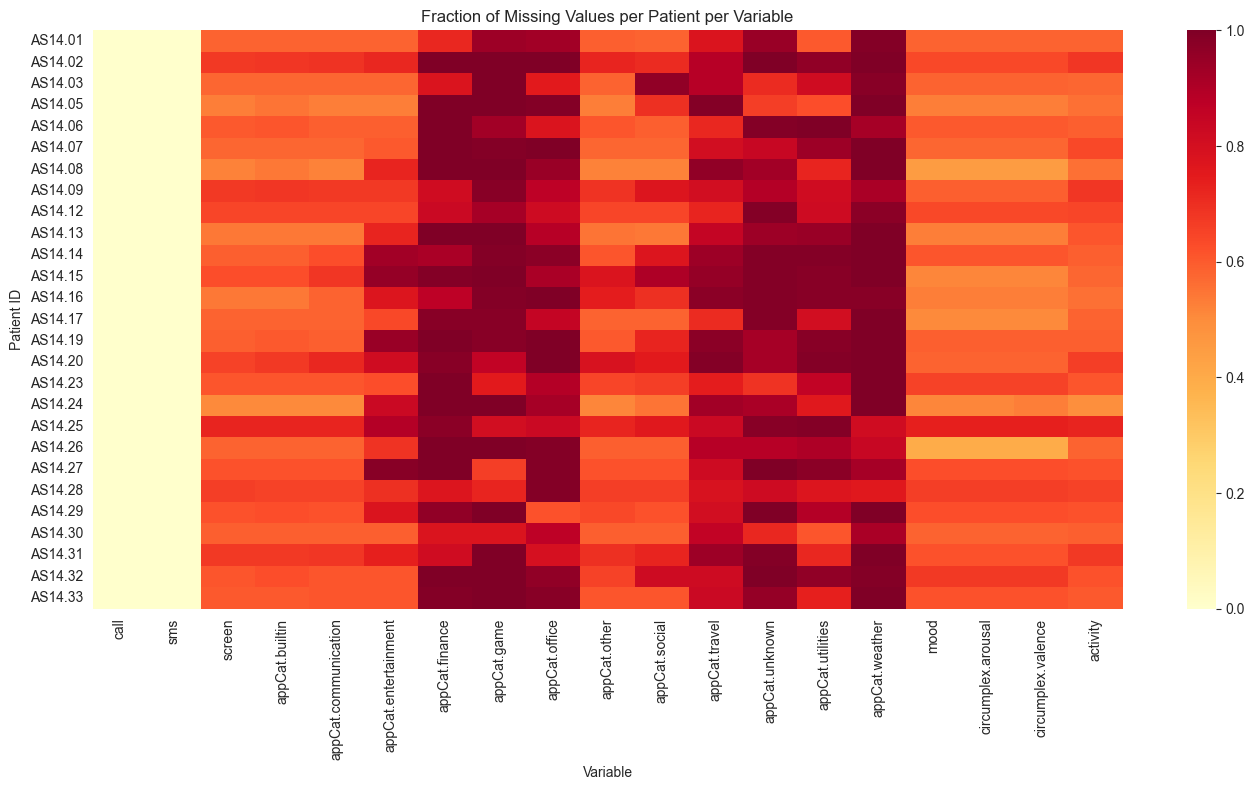


=== Percentage missing per variable ===
  appCat.weather                :  96.3%
  appCat.game                   :  93.7%
  appCat.finance                :  93.2%
  appCat.unknown                :  91.3%
  appCat.office                 :  91.0%
  appCat.travel                 :  85.9%
  appCat.utilities              :  85.8%
  appCat.entertainment          :  72.1%
  appCat.social                 :  67.6%
  appCat.other                  :  63.3%
  appCat.communication          :  61.2%
  activity                      :  61.1%
  appCat.builtin                :  60.8%
  screen                        :  60.4%
  circumplex.valence            :  58.5%
  mood                          :  58.4%
  circumplex.arousal            :  58.4%
  sms                           :   0.0%
  call                          :   0.0%

=== Prolonged gaps (>7 consecutive missing days) ===
  Patient AS14.01, screen: max consecutive gap = 35 days
  Patient AS14.01, appCat.builtin: max consecutive gap = 35 days
  Pa

In [5]:
# Heatmap of missing values per patient per variable
fig, ax = plt.subplots(figsize=(14, 8))
missing_by_patient = df_wide.groupby('id')[variable_cols].apply(
    lambda x: x.isnull().mean()
)
sns.heatmap(missing_by_patient, cmap='YlOrRd', ax=ax, vmin=0, vmax=1)
ax.set_title('Fraction of Missing Values per Patient per Variable')
ax.set_xlabel('Variable')
ax.set_ylabel('Patient ID')
plt.tight_layout()
plt.show()

# Percentage missing per variable
print("\n=== Percentage missing per variable ===")
pct_missing = (df_wide[variable_cols].isnull().sum() / len(df_wide) * 100).sort_values(ascending=False)
for col, pct in pct_missing.items():
    print(f"  {col:30s}: {pct:5.1f}%")

# Identify prolonged gaps (>7 consecutive days) per patient
print("\n=== Prolonged gaps (>7 consecutive missing days) ===")
for patient in sorted(df_wide['id'].unique()):
    p_data = df_wide[df_wide['id'] == patient]
    for col in variable_cols:
        is_na = p_data[col].isna()
        groups = (~is_na).cumsum()
        gap_sizes = is_na.groupby(groups).transform('sum')
        max_gap = gap_sizes.max() if is_na.any() else 0
        if max_gap > 7:
            print(f"  Patient {patient}, {col}: max consecutive gap = {int(max_gap)} days")

## 5. Imputation
We compare three imputation methods for time series data: Forward Fill (LOCF), Linear Interpolation, and MICE (IterativeImputer). Gaps longer than 7 consecutive days are not imputed, as the patient's state may have changed substantially.

In [6]:
# Setup long gap detection
MAX_GAP_DAYS = 7

def get_long_gap_mask(series, max_gap):
    """Return a boolean mask marking positions that are part of a gap longer than max_gap."""
    is_na = series.isna()
    groups = (~is_na).cumsum()
    gap_sizes = is_na.groupby(groups).transform('sum')
    return is_na & (gap_sizes > max_gap)

# Create long_gap_masks dict for each (patient, variable) pair
long_gap_masks = {}
for patient in df_wide['id'].unique():
    patient_data = df_wide[df_wide['id'] == patient]
    for col in variable_cols:
        mask = get_long_gap_mask(patient_data[col], MAX_GAP_DAYS)
        long_gap_masks[(patient, col)] = mask

total_long_gap = sum(m.sum() for m in long_gap_masks.values())
print(f"Values in gaps longer than {MAX_GAP_DAYS} days (will NOT be imputed): {total_long_gap}")

Values in gaps longer than 7 days (will NOT be imputed): 36506


In [7]:
# Method 1: Forward Fill (LOCF)
df_ffill = df_wide.copy()

for patient in df_ffill['id'].unique():
    mask = df_ffill['id'] == patient
    idx = df_ffill.loc[mask].index
    df_ffill.loc[idx, variable_cols] = df_ffill.loc[idx, variable_cols].ffill()
    
    # Restore NaN for long gaps
    for col in variable_cols:
        gap_mask = long_gap_masks.get((patient, col))
        if gap_mask is not None and gap_mask.any():
            gap_indices = gap_mask[gap_mask].index
            df_ffill.loc[gap_indices, col] = np.nan

print("Method 1: Forward Fill (LOCF)")
print(f"  Remaining NaN: {df_ffill[variable_cols].isnull().sum().sum()}")

Method 1: Forward Fill (LOCF)
  Remaining NaN: 36506


In [8]:
# Method 2: Linear Interpolation
df_interp = df_wide.copy()

for patient in df_interp['id'].unique():
    mask = df_interp['id'] == patient
    idx = df_interp.loc[mask].index
    df_interp.loc[idx, variable_cols] = df_interp.loc[idx, variable_cols].interpolate(
        method='linear', limit_direction='both'
    )
    
    # Restore NaN for long gaps
    for col in variable_cols:
        gap_mask = long_gap_masks.get((patient, col))
        if gap_mask is not None and gap_mask.any():
            gap_indices = gap_mask[gap_mask].index
            df_interp.loc[gap_indices, col] = np.nan

print("Method 2: Linear Interpolation")
print(f"  Remaining NaN: {df_interp[variable_cols].isnull().sum().sum()}")

Method 2: Linear Interpolation
  Remaining NaN: 36506


In [9]:
# Method 3: MICE (IterativeImputer)
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

df_mice = df_wide.copy()

for patient in df_mice['id'].unique():
    mask = df_mice['id'] == patient
    patient_data = df_mice.loc[mask, variable_cols].copy()
    
    # IterativeImputer drops columns that are all-NaN, so we only pass columns
    # that have at least one non-NaN value
    valid_cols = [c for c in variable_cols if patient_data[c].notna().any()]
    
    if len(valid_cols) > 0 and patient_data[valid_cols].isnull().any().any():
        imputer = IterativeImputer(max_iter=10, random_state=42)
        imputed = imputer.fit_transform(patient_data[valid_cols])
        df_mice.loc[mask, valid_cols] = imputed
    
    # Restore NaN for long gaps
    for col in variable_cols:
        gap_mask = long_gap_masks.get((patient, col))
        if gap_mask is not None and gap_mask.any():
            gap_indices = gap_mask[gap_mask].index
            df_mice.loc[gap_indices, col] = np.nan

print("Method 3: MICE (IterativeImputer)")
print(f"  Remaining NaN: {df_mice[variable_cols].isnull().sum().sum()}")

Method 3: MICE (IterativeImputer)
  Remaining NaN: 36506


## 6. Imputation Comparison
We compare the three methods by examining how well they preserve the original distribution statistics and visual patterns.

In [10]:
# Quantitative comparison
compare_vars = ['mood', 'circumplex.arousal', 'circumplex.valence', 'screen', 'activity']
rows = []

for var in compare_vars:
    for label, data in [('Original', df_wide), ('Forward Fill', df_ffill),
                         ('Interpolation', df_interp), ('MICE', df_mice)]:
        vals = data[var].dropna()
        rows.append({
            'Variable': var, 'Method': label,
            'Mean': round(vals.mean(), 3), 'Std': round(vals.std(), 3),
            'Median': round(vals.median(), 3), 'Count': len(vals)
        })

comparison_df = pd.DataFrame(rows)
for var in compare_vars:
    print(f"\n--- {var} ---")
    display(comparison_df[comparison_df['Variable'] == var][['Method', 'Mean', 'Std', 'Median', 'Count']].to_string(index=False))


--- mood ---


'       Method  Mean   Std  Median  Count\n     Original 6.990 0.736     7.0   1268\n Forward Fill 6.998 0.734     7.0   1300\nInterpolation 6.996 0.732     7.0   1300\n         MICE 6.997 0.733     7.0   1300'


--- circumplex.arousal ---


'       Method   Mean   Std  Median  Count\n     Original -0.104 0.663     0.0   1268\n Forward Fill -0.103 0.670     0.0   1300\nInterpolation -0.101 0.665     0.0   1300\n         MICE -0.099 0.658     0.0   1300'


--- circumplex.valence ---


'       Method  Mean   Std  Median  Count\n     Original 0.687 0.435     0.8   1266\n Forward Fill 0.689 0.433     0.8   1300\nInterpolation 0.688 0.433     0.8   1300\n         MICE 0.688 0.431     0.8   1300'


--- screen ---


'       Method     Mean      Std   Median  Count\n     Original 6027.940 4696.747 5026.948   1207\n Forward Fill 5940.625 4701.284 4957.294   1229\nInterpolation 5938.038 4703.224 4957.294   1229\n         MICE 5956.904 4689.379 4964.636   1229'


--- activity ---


'       Method  Mean   Std  Median  Count\n     Original 0.120 0.098   0.096   1188\n Forward Fill 0.121 0.100   0.096   1197\nInterpolation 0.120 0.099   0.096   1197\n         MICE 0.120 0.098   0.096   1197'

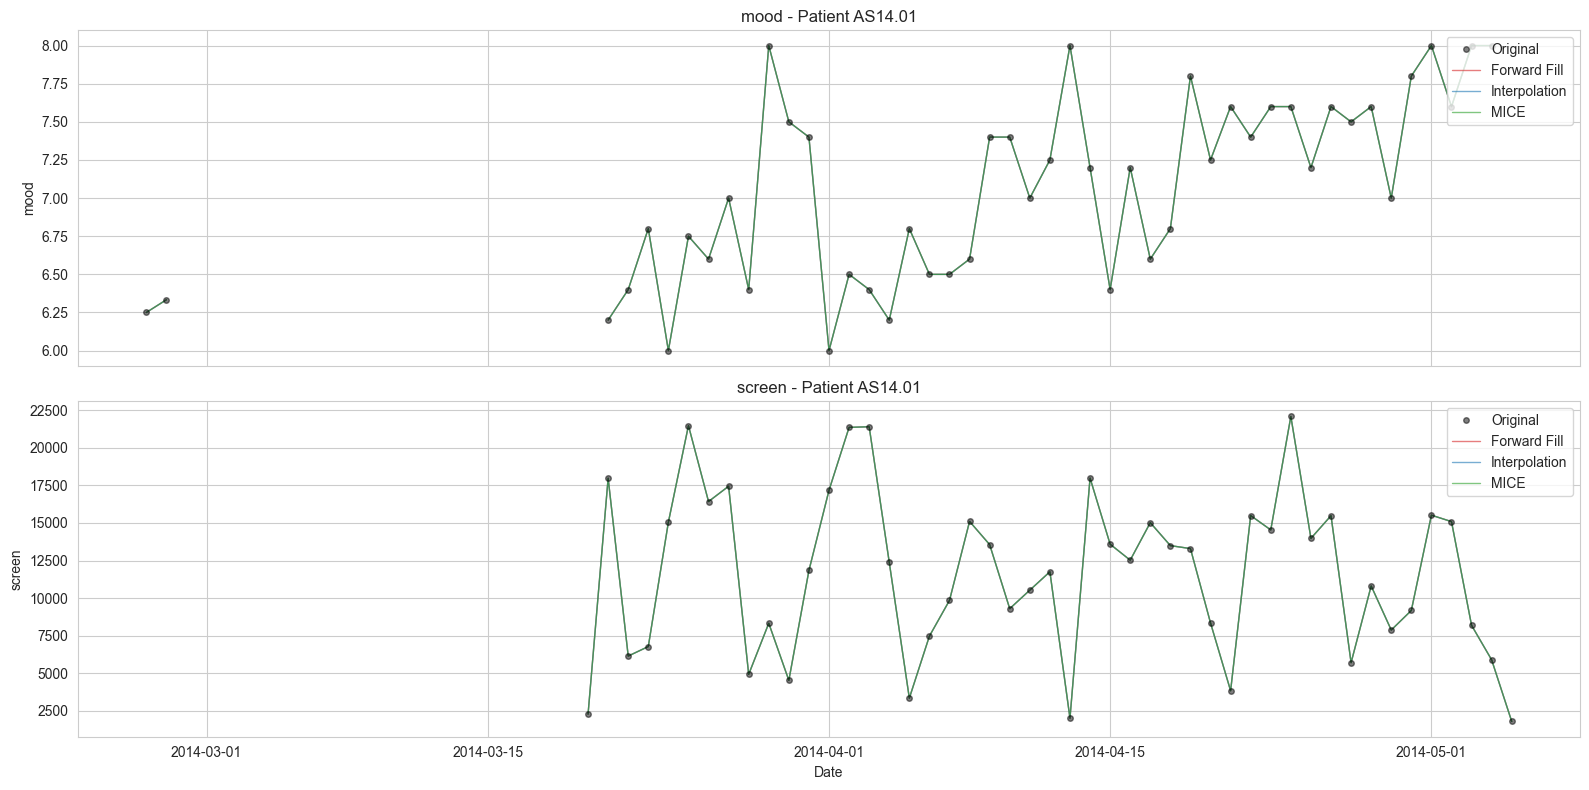

In [11]:
# Visual comparison: first patient, mood and screen time series
sample_patient = df_wide['id'].unique()[0]

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

for ax, var in zip(axes, ['mood', 'screen']):
    p_mask = df_wide['id'] == sample_patient
    dates = df_wide.loc[p_mask, 'date']
    
    ax.plot(dates, df_wide.loc[p_mask, var], 'ko', markersize=4, alpha=0.5, label='Original', zorder=5)
    ax.plot(dates, df_ffill.loc[p_mask, var], '-', color='tab:red', alpha=0.6, linewidth=1, label='Forward Fill')
    ax.plot(dates, df_interp.loc[p_mask, var], '-', color='tab:blue', alpha=0.6, linewidth=1, label='Interpolation')
    ax.plot(dates, df_mice.loc[p_mask, var], '-', color='tab:green', alpha=0.6, linewidth=1, label='MICE')
    ax.set_ylabel(var)
    ax.set_title(f'{var} - Patient {sample_patient}')
    ax.legend(loc='upper right')

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()

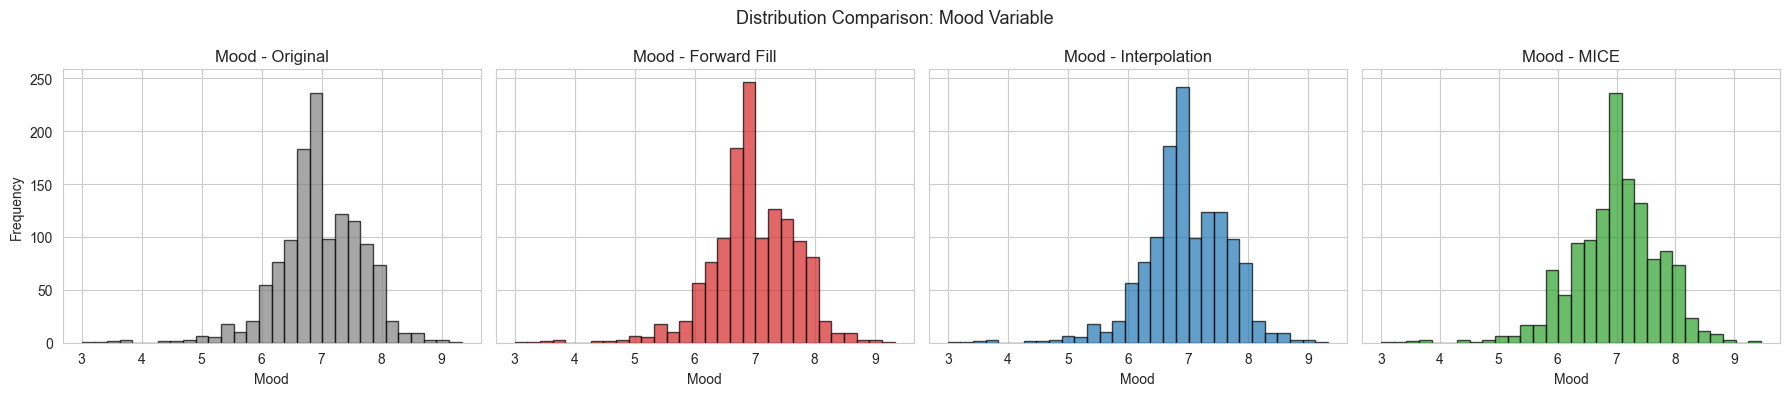

In [12]:
# Distribution comparison: histograms for mood
fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)

titles = ['Original', 'Forward Fill', 'Interpolation', 'MICE']
datasets = [df_wide, df_ffill, df_interp, df_mice]
colors = ['gray', 'tab:red', 'tab:blue', 'tab:green']

for ax, title, data, color in zip(axes, titles, datasets, colors):
    ax.hist(data['mood'].dropna(), bins=30, color=color, edgecolor='black', alpha=0.7)
    ax.set_title(f'Mood - {title}')
    ax.set_xlabel('Mood')
axes[0].set_ylabel('Frequency')

plt.suptitle('Distribution Comparison: Mood Variable', fontsize=13)
plt.tight_layout()
plt.show()

## 7. Imputation Selection

Comparing the three methods:

- **LOCF (Forward Fill)**: Creates step patterns and inflates the frequency of observed values. Simple and preserves observed data, but does not capture temporal trends. Mood distributions show artificial spikes at commonly observed values.
- **Linear Interpolation**: Produces smoother trajectories that respect temporal ordering. Better variance preservation and more realistic distributions. Assumes linearity between observations, which is reasonable for short gaps.
- **MICE (IterativeImputer)**: Considers multivariate relationships between variables, which can be powerful. However, it does not respect temporal ordering (treats rows as exchangeable), may introduce noise in sparse data, and is computationally more expensive.

**Recommendation**: We select **linear interpolation** as the primary method. It respects temporal trends, preserves distributional properties well, and is appropriate for the short gaps we impute (up to 7 days). MICE is powerful for cross-sectional data but ignores the time structure that is central to this longitudinal dataset. For call and sms (event counts), we already filled missing values with 0 since absence of a row means no event occurred.

## 8. Log Transformation of Skewed Variables
App usage durations and screen time are heavily right-skewed (log-distributed). We apply log1p transformation to normalize these distributions, which can improve model performance.

=== Skewness before and after log1p transformation ===
            Variable  Skew (before)  Skew (after log1p)
              screen           1.14               -1.89
      appCat.builtin           6.89               -0.66
appCat.communication           1.65               -1.42
appCat.entertainment           9.10               -0.49
      appCat.finance           5.51                0.09
         appCat.game           6.25               -0.55
       appCat.office          16.71                0.23
        appCat.other           6.50                0.57
       appCat.social           6.26               -0.49
       appCat.travel          11.11               -0.47
      appCat.unknown           5.69               -0.38
    appCat.utilities           5.40                0.60
      appCat.weather           3.86               -0.26


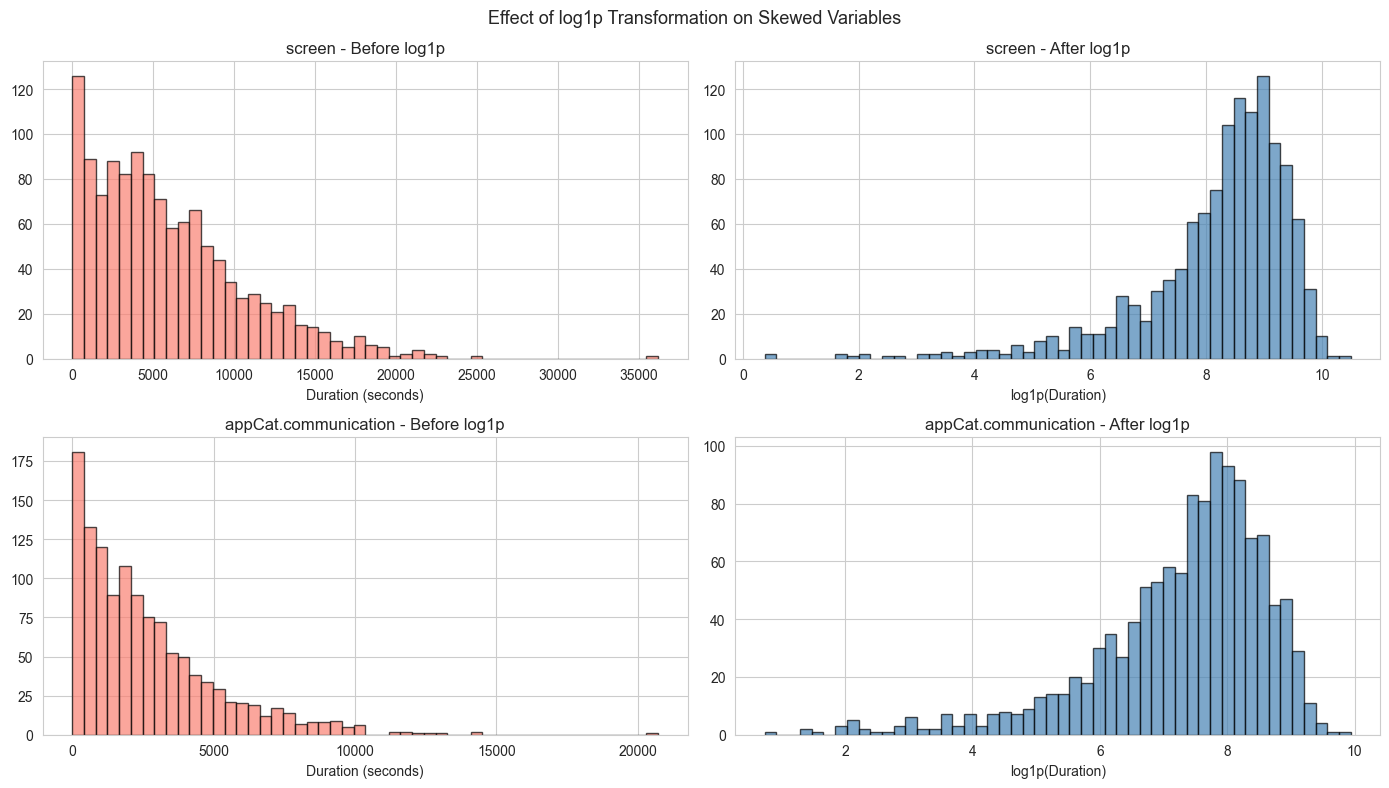

In [13]:
# Identify skewed variables (screen + all appCat.*)
skewed_vars = [c for c in variable_cols if c.startswith('appCat.') or c == 'screen']

df_final = df_interp.copy()

# Show before/after skewness
skew_comparison = []
for var in skewed_vars:
    before_skew = df_final[var].dropna().skew()
    after_vals = np.log1p(df_final[var].dropna().clip(lower=0))
    after_skew = after_vals.skew()
    skew_comparison.append({'Variable': var, 'Skew (before)': round(before_skew, 2),
                            'Skew (after log1p)': round(after_skew, 2)})

skew_df = pd.DataFrame(skew_comparison)
print("=== Skewness before and after log1p transformation ===")
print(skew_df.to_string(index=False))

# Apply log1p to skewed variables (clip negative values to 0 first, just in case)
for var in skewed_vars:
    df_final[var] = np.log1p(df_final[var].clip(lower=0))

# Before/after histograms for screen and appCat.communication
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Screen
axes[0, 0].hist(df_interp['screen'].dropna(), bins=50, color='salmon', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('screen - Before log1p')
axes[0, 0].set_xlabel('Duration (seconds)')

axes[0, 1].hist(df_final['screen'].dropna(), bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('screen - After log1p')
axes[0, 1].set_xlabel('log1p(Duration)')

# appCat.communication
comm_col = 'appCat.communication' if 'appCat.communication' in variable_cols else skewed_vars[1]
axes[1, 0].hist(df_interp[comm_col].dropna(), bins=50, color='salmon', edgecolor='black', alpha=0.7)
axes[1, 0].set_title(f'{comm_col} - Before log1p')
axes[1, 0].set_xlabel('Duration (seconds)')

axes[1, 1].hist(df_final[comm_col].dropna(), bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[1, 1].set_title(f'{comm_col} - After log1p')
axes[1, 1].set_xlabel('log1p(Duration)')

plt.suptitle('Effect of log1p Transformation on Skewed Variables', fontsize=13)
plt.tight_layout()
plt.show()

## 9. Save Cleaned Dataset

In [14]:
# Save final dataset (interpolated + log-transformed)
output_path = '../data/dataset_mood_smartphone_cleaned.csv'
df_final.to_csv(output_path, index=False)
print(f"Saved cleaned dataset to: {output_path}")

# Also save version without log transform for reference
df_nolog = df_interp.copy()
df_nolog.to_csv('../data/dataset_mood_smartphone_cleaned_nolog.csv', index=False)
print(f"Saved non-log version to: ../data/dataset_mood_smartphone_cleaned_nolog.csv")

# Final summary
print(f"\n=== Final Dataset Summary ===")
print(f"  Shape: {df_final.shape}")
print(f"  Patients: {df_final['id'].nunique()}")
print(f"  Date range: {df_final['date'].min().date()} to {df_final['date'].max().date()}")
print(f"  Total remaining NaN: {df_final[variable_cols].isnull().sum().sum()}")
print(f"\n  Remaining NaN per column:")
remaining = df_final[variable_cols].isnull().sum()
remaining = remaining[remaining > 0]
if len(remaining) > 0:
    for col, n in remaining.items():
        print(f"    {col}: {n}")
else:
    print("    None")

Saved cleaned dataset to: ../data/dataset_mood_smartphone_cleaned.csv
Saved non-log version to: ../data/dataset_mood_smartphone_cleaned_nolog.csv

=== Final Dataset Summary ===
  Shape: (3051, 21)
  Patients: 27
  Date range: 2014-02-17 to 2014-06-09
  Total remaining NaN: 36506

  Remaining NaN per column:
    screen: 1822
    appCat.builtin: 1829
    appCat.communication: 1825
    appCat.entertainment: 2027
    appCat.finance: 2685
    appCat.game: 2781
    appCat.office: 2576
    appCat.other: 1850
    appCat.social: 1914
    appCat.travel: 2322
    appCat.unknown: 2589
    appCat.utilities: 2358
    appCat.weather: 2821
    mood: 1751
    circumplex.arousal: 1751
    circumplex.valence: 1751
    activity: 1854


## Summary

**Domain cleaning**: Fixed negative sensor errors in app duration variables. Small negatives (rounding errors) were converted to absolute values, while the extreme value (-82798 in appCat.builtin) was set to NaN as a clear sensor malfunction. Arousal and valence negatives were left intact (valid range -2 to 2). Call and sms missing values were filled with 0, since absence of a row means no event.

**No IQR-based outlier removal**: App usage durations are naturally log-distributed with heavy right tails. IQR-based filtering would remove legitimate heavy users. Instead, we only applied domain-based bounds and handled clearly erroneous values.

**Imputation**: Compared Forward Fill (LOCF), Linear Interpolation, and MICE (IterativeImputer). Selected linear interpolation because it respects temporal trends and preserves distributional properties better than LOCF (which creates step patterns) and MICE (which ignores temporal ordering). Gaps longer than 7 consecutive days were left as NaN intentionally.

**Log transformation**: Applied log1p to right-skewed duration variables (screen, appCat.*) to normalize distributions for downstream modeling. Both transformed and untransformed versions are saved.